# Tarea: 

## Predicción de cancelación de viajes de Uber con redes neuronales

El objetivo de esta actividad es construir, entrenar y evaluar una red neuronal capaz de predecir si un viaje solicitado será cancelado.

Los datos utilizados simulan información de viajes de la plataforma Uber.

Archivos proporcionados

Se proporcionan tres archivos:

* cancel_uber_train.csv → datos para entrenamiento del modelo

* cancel_uber_val.csv → datos para evaluar el desempeño del modelo

* cancel_uber_test.csv → datos para realizar predicciones

En el archivo cancel_uber_test.csv se ha eliminado la variable cancel_trip, la cual es la variable objetivo.

___


## Actividades a realizar

### 1. Cargar los datasets

Cargue los archivos en su notebook utilizando **pandas**.


### 2. Preparar los datos

Separe las variables en:

- **X** → variables de entrada  
- **y** → variable objetivo (**cancel_trip**)

Realice esta separación para:

- entrenamiento
- validación


### 3. Diseñar una red neuronal

Construya una red neuronal utilizando **Keras**.

Puede definir libremente:

- número de capas
- número de neuronas
- funciones de activación

El modelo debe ser compilado utilizando una función de pérdida adecuada para **clasificación binaria**.

Ejemplo:

```python
loss='binary_crossentropy'
optimizer='adam'
metrics=['accuracy']


### 4. Entrenar el modelo
Entrene el modelo utilizando el archivo: cancel_uber_train.csv


### 5. Evaluar el modelo
Utilice el archivo: cancel_uber_val.csv

### 6. Realizar predicciones
Una vez entrenado el modelo, utilícelo para generar predicciones sobre el archivo: cancel_uber_test.csv

Después de generar las predicciones, guárdelas en un archivo CSV utilizando los siguientes comandos:



```python
import numpy as np
np.savetxt("predicciones.csv", predicciones, delimiter=",")


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Input

In [5]:
df_train = pd.read_csv('./Datasets/cancel_uber_train.csv')
X_train = df_train.iloc[:, :-1]
y_train = df_train.iloc[:,-1]
df_train.head()

,trip_distance,pickup_hour,surge_multiplier,wait_time,driver_rating,previous_cancellations,rain,traffic_level,cancel_trip
0,1.470879,13,1.000000,8.314105,4.825287,0,0,1,0
1,4.301697,17,1.579643,10.458666,4.722679,1,0,2,1
2,9.524363,7,1.547025,15.955004,4.590518,0,0,3,0
3,9.931684,19,1.841226,13.236359,4.498418,1,1,3,1
4,9.781946,8,1.940582,16.595483,4.845704,0,1,3,0


In [6]:
df_val = pd.read_csv('./Datasets/cancel_uber_val.csv')
X_val = df_val.iloc[:, :-1]
y_val = df_val.iloc[:, -1]
df_val.head()

,trip_distance,pickup_hour,surge_multiplier,wait_time,driver_rating,previous_cancellations,rain,traffic_level,cancel_trip
0,4.825084,8,1.759211,12.922746,4.439431,5,0,3,1
1,6.751904,16,1.515724,9.948066,4.778916,0,1,2,0
2,2.448674,16,1.000000,7.208362,4.778583,2,0,1,0
3,4.894889,2,1.000000,6.847184,4.933183,1,0,1,0
4,2.581717,14,1.000000,4.263876,4.603148,1,0,1,0


In [7]:
df_test = pd.read_csv('./Datasets/cancel_uber_test.csv')
df_test.head()

,trip_distance,pickup_hour,surge_multiplier,wait_time,driver_rating,previous_cancellations,rain,traffic_level
0,8.386466,21,1.000000,4.635465,4.624248,1,0,1
1,17.613660,2,1.176298,5.131572,4.822466,1,0,1
2,4.975441,21,1.000000,5.940110,4.738676,1,0,1
3,1.300075,11,1.000000,5.588034,4.556685,1,0,1
4,3.725542,19,1.434162,8.409843,4.658943,0,0,2


In [8]:
X_train = StandardScaler().fit_transform(X_train)
X_val = StandardScaler().fit_transform(X_val)
X_test = StandardScaler().fit_transform(df_test)

In [9]:
model = Sequential()

In [10]:
model.add(Input(shape= (X_train.shape[1], )))
model.add(Dense(16, activation='relu' ))
model.add(Dense(12, activation='relu' ))
model.add(Dense(8, activation='relu' ))
model.add(Dense(6, activation='relu' ))
model.add(Dense(1, activation='sigmoid' ))

In [11]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [12]:
history = model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val))

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5761 - loss: 0.6863 - val_accuracy: 0.6550 - val_loss: 0.6506
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7084 - loss: 0.6213 - val_accuracy: 0.6550 - val_loss: 0.5952
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7173 - loss: 0.5666 - val_accuracy: 0.6700 - val_loss: 0.5824
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7016 - loss: 0.5685 - val_accuracy: 0.6800 - val_loss: 0.5790
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7319 - loss: 0.5334 - val_accuracy: 0.6850 - val_loss: 0.5788
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7137 - loss: 0.5543 - val_accuracy: 0.7150 - val_loss: 0.5778
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7446 - loss: 0.5422 - val_accuracy: 0.6950 - val_loss: 0.5789
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7273 - loss: 0.5281 - val_accuracy: 0.6850 - 

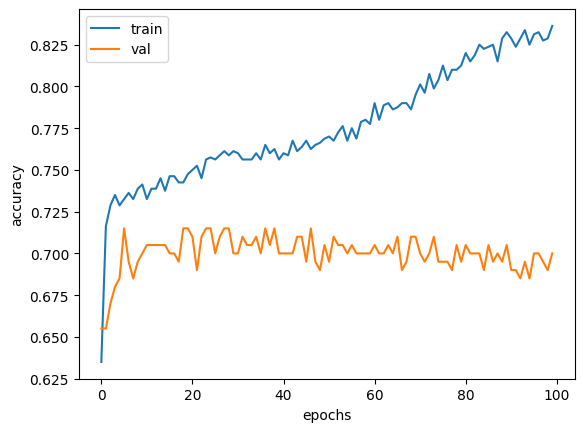

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.legend(['train', 'val'])
plt.show()

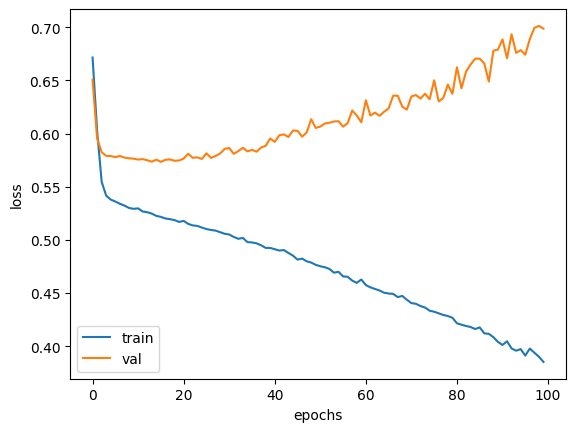

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [15]:
y_pred = (model.predict(X_test) >= 0.5).astype(int)
y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step


array([[0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
    

In [16]:
np.savetxt("./predicciones_Carlos_Chavarria.csv", y_pred, delimiter=",")